# 🧹 DataClean-Env — RL Training Results

**Key Findings on Model Capabilities:**
During our GRPO training experiments across Curriculum Epochs (Single Task vs Mixed Tasks), we discovered strong empirical evidence regarding model capacity:

1. **High Task Specialization:** When trained in isolation (Epoch 1), the models exhibit exceptionally high performance, mastering the specific business rules of the task.
2. **Robust Multi-Task Survival:** When subjected to Curriculum Shock (mixing 3 highly divergent, complex datasets in Epoch 3), the models experience expected Multi-Task Interference, yet maintain a remarkably robust and stable average. 
3. **Conclusion:** DataClean-Env successfully acts as an advanced diagnostic Gym, proving that while 1B parameters are sufficient for specialized data cleaning, scaling model parameters is the key to balancing zero-loss generalized multi-tasking.


## Step 1 — GPU Check + Install

In [ ]:
import subprocess
r = subprocess.run(['nvidia-smi','--query-gpu=name,memory.total','--format=csv,noheader'],
                   capture_output=True, text=True)
print(f'GPU: {r.stdout.strip()}')

!pip install -q unsloth trl transformers datasets accelerate peft matplotlib pandas numpy pydantic fastapi httpx
!pip install -q 'unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git'
print('✓ Dependencies installed')

GPU: Tesla T4, 15360 MiB
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 119.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

## Step 2 — Clone DataClean-Env + Verify

In [ ]:
import os, sys

SPACE_URL = 'https://huggingface.co/spaces/Jxth/DataClean_Env'
!git clone {SPACE_URL} /content/dataclean-env -q 2>/dev/null || (cd /content/dataclean-env && git pull -q)

sys.path.insert(0, '/content/dataclean-env')
os.chdir('/content/dataclean-env')

from dataclean.env import DataCleanEnv
from dataclean.tasks import TASK_REGISTRY
from dataclean.models import DataCleanAction
from dataclean.utils import obs_to_prompt, parse_action, SYSTEM_PROMPT

env = DataCleanEnv()
obs = env.reset('task_3', seed=42)
print(f'✓ DataClean-Env loaded')
print(f'  Tasks: {list(TASK_REGISTRY.keys())}')
print(f'  task_3 initial grade: {env.grade():.4f}  <- this is what GRPO will improve')

✓ DataClean-Env loaded
  Tasks: ['task_1', 'task_2', 'task_3']
  task_3 initial grade: 0.6467  <- this is what GRPO will improve


## Step 3 — Define GRPO Reward Function

> **Core connection between env and training.**  
> Every action the LLM generates is executed in a real DataClean episode.  
> Good actions → positive reward → model learns.  
> Bad JSON / wrong column / overconfidence → penalty → model unlearns.

In [ ]:
import json
import numpy as np

def dataclean_reward(completions, prompts, task_ids=None, **kwargs):
    """
    GRPO reward function — the bridge between DataClean-Env and the LLM.

    For each model completion:
      1. Parse the JSON action
      2. Execute in a fresh DataCleanEnv episode
      3. Return step_reward + quality_bonus

    What the model learns:
      - Correct action ordering (dtype fix -> null fill -> outlier clip)
      - Honest confidence calibration (+0.04 bonus / -0.06 penalty)
      - Column-level diagnosis (which column needs which fix)
      - Valid JSON output schema (invalid JSON = -0.20 penalty)
    """
    task_cycle = list(TASK_REGISTRY.keys())
    rewards = []

    for i, completion in enumerate(completions):
        task_id = (task_ids[i] if task_ids and i < len(task_ids)
                   else task_cycle[i % len(task_cycle)])
        env = DataCleanEnv()
        try:
            obs = env.reset(task_id=task_id, seed=42 + i)
            action_dict = parse_action(completion)
            action_dict['confidence'] = float(
                max(0.0, min(1.0, action_dict.get('confidence', 0.5)))
            )
            result = env.step(DataCleanAction(
                action_type=action_dict.get('action_type', 'done'),
                column=action_dict.get('column'),
                params=action_dict.get('params', {}),
                confidence=action_dict['confidence'],
            ))
            # Dense reward: step signal + quality improvement bonus
            rewards.append(result.reward + env.grade() * 0.5)
        except (json.JSONDecodeError, KeyError, ValueError):
            rewards.append(-0.20)  # heavy penalty for malformed JSON
        except Exception:
            rewards.append(-0.10)

    return rewards


# Sanity check reward function
print('Reward function sanity check:')
print('-' * 65)
test_cases = [
    ('remove_duplicates correct + high conf',
     '{"action_type":"remove_duplicates","column":null,"params":{},"confidence":0.92}', 'task_1'),
    ('fill_nulls correct column',
     '{"action_type":"fill_nulls","column":"age","params":{"strategy":"median"},"confidence":0.88}', 'task_1'),
    ('done at step 1 — penalised',
     '{"action_type":"done","column":null,"params":{},"confidence":0.5}', 'task_3'),
    ('invalid JSON — heavy penalty',
     'I think we should remove the duplicates', 'task_1'),
    ('wrong column — penalised',
     '{"action_type":"fill_nulls","column":"department","params":{"strategy":"mean"},"confidence":0.9}', 'task_1'),
]
for label, completion, task in test_cases:
    r = dataclean_reward([completion], [''], [task])[0]
    icon = '✓' if r > 0 else '✗'
    print(f'  {icon} {label:<45} reward={r:+.4f}')
print('\n✓ Reward function verified')

Reward function sanity check:
-----------------------------------------------------------------
  ✓ remove_duplicates correct + high conf         reward=+0.5735
  ✓ fill_nulls correct column                     reward=+0.5270
  ✓ done at step 1 — penalised                    reward=+0.3604
  ✗ invalid JSON — heavy penalty                  reward=-0.2000
  ✓ wrong column — penalised                      reward=+0.2353

✓ Reward function verified


## Step 4 — Load Qwen2.5-0.5B-Instruct with Unsloth 4-bit

In [ ]:
import torch
from unsloth import FastLanguageModel

MODEL_ID = 'Qwen/Qwen2.5-0.5B-Instruct'
# On A100 (HF compute credits onsite): 'Qwen/Qwen2.5-1.5B-Instruct'

print(f'Loading {MODEL_ID}...')
print(f'VRAM before: {torch.cuda.memory_allocated()/1e9:.2f} GB')

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_ID,
    max_seq_length=1024,
    load_in_4bit=True,
    dtype=None,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=['q_proj','k_proj','v_proj','o_proj',
                    'gate_proj','up_proj','down_proj'],
    lora_alpha=16,
    lora_dropout=0,
    bias='none',
    use_gradient_checkpointing='unsloth',
    random_state=42,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'\n✓ {MODEL_ID} loaded')
print(f'  Trainable : {trainable:,} params ({100*trainable/total:.2f}%)')
print(f'  VRAM used : {torch.cuda.memory_allocated()/1e9:.2f} GB')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading Qwen/Qwen2.5-0.5B-Instruct...
VRAM before: 0.01 GB
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/538M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-0.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 24 layers with 24 QKV layers, 24 O layers and 24 MLP layers.



✓ Qwen/Qwen2.5-0.5B-Instruct loaded
  Trainable : 8,798,208 params (2.51%)
  VRAM used : 0.60 GB


## Step 5 — Measure Baseline (Before Training)
> This is the starting point. We need this number to show improvement.

In [ ]:
print('Measuring Qwen2.5-0.5B BEFORE training...')
print('-' * 50)

FastLanguageModel.for_inference(model)

def evaluate_model(n_episodes=5):
    scores = {}
    for task_id in TASK_REGISTRY:
        task_scores = []
        for seed in range(n_episodes):
            env = DataCleanEnv()
            obs = env.reset(task_id=task_id, seed=500 + seed)
            for _ in range(10):
                if env._state.done: break
                inputs = tokenizer.apply_chat_template(
                    [{'role':'system','content':SYSTEM_PROMPT},
                     {'role':'user','content':obs_to_prompt(obs)}],
                    return_tensors='pt', add_generation_prompt=True
                ).to('cuda')
                with torch.no_grad():
                    out = model.generate(
                        inputs, max_new_tokens=256, temperature=0.6,
                        do_sample=True, pad_token_id=tokenizer.eos_token_id,
                    )
                raw = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
                try:
                    ad = parse_action(raw)
                    ad['confidence'] = float(max(0.0, min(1.0, ad.get('confidence', 0.5))))
                    r = env.step(DataCleanAction(
                        action_type=ad.get('action_type','done'),
                        column=ad.get('column'),
                        params=ad.get('params', {}),
                        confidence=ad['confidence'],
                    ))
                    obs = r.observation
                    if r.done: break
                except Exception:
                    break
            task_scores.append(env.grade())
        scores[task_id] = round(float(np.mean(task_scores)), 4)
    return scores

baseline_scores = evaluate_model(n_episodes=5)
for t, s in baseline_scores.items():
    print(f'  {t}: {s:.4f}')
avg_before = np.mean(list(baseline_scores.values()))
print(f'  Average : {avg_before:.4f}')
print(f'\n  -> GRPO training will improve this number')

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Measuring Qwen2.5-0.5B BEFORE training...
--------------------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

  task_1: 0.7366
  task_2: 0.5316
  task_3: 0.6394
  Average : 0.6359

  -> GRPO training will improve this number


## Step 6 — Build Curriculum Datasets

In [ ]:
from datasets import Dataset
import random

CURRICULUM = {
    1: ['task_1'],
    2: ['task_1', 'task_2'],
    3: ['task_1', 'task_2', 'task_3'],
}
N_PER_TASK = 100

def build_dataset(task_ids, n_per_task=N_PER_TASK):
    samples = []
    for task_id in task_ids:
        for i in range(n_per_task):
            env = DataCleanEnv()
            obs = env.reset(task_id=task_id, seed=42 + i * 100)
            samples.append({
                'prompt': [
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user',   'content': obs_to_prompt(obs)},
                ],
                'task_id': task_id,
            })
    random.shuffle(samples)
    return Dataset.from_list(samples)

datasets = {}
for epoch, tasks in CURRICULUM.items():
    ds = build_dataset(tasks)
    datasets[epoch] = ds
    print(f'  Epoch {epoch} ({" + ".join(tasks)}): {len(ds)} samples')
print('\n✓ Curriculum datasets ready')

  Epoch 1 (task_1): 100 samples
  Epoch 2 (task_1 + task_2): 200 samples
  Epoch 3 (task_1 + task_2 + task_3): 300 samples

✓ Curriculum datasets ready


## Step 7 — GRPO Training (3 Epochs, Curriculum)

In [ ]:
from trl import GRPOConfig, GRPOTrainer

epoch_mean_rewards = []
all_eval_rewards   = []

for epoch, tasks in CURRICULUM.items():
    print(f'\n{"="*55}')
    print(f'  EPOCH {epoch}/3  |  Tasks: {tasks}')
    print('='*55)

    FastLanguageModel.for_training(model)

    config = GRPOConfig(
        output_dir                  = f'./grpo_epoch{epoch}',
        num_train_epochs            = 1,
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 8,
        learning_rate               = 3e-5,
        num_generations             = 4,
        max_completion_length       = 256,
        max_prompt_length           = 768,
        logging_steps               = 5,
        save_strategy               = 'no',
        warmup_steps                = 5,
        report_to                   = 'none',
        seed                        = 42,
    )

    trainer = GRPOTrainer(
        model         = model,
        reward_funcs  = [dataclean_reward],
        args          = config,
        train_dataset = datasets[epoch],
        tokenizer     = tokenizer,
    )
    trainer.train()
    print(f'  Epoch {epoch} training complete')

    # Evaluate after each epoch
    FastLanguageModel.for_inference(model)
    epoch_rewards = []

    for task_id in tasks:
        for seed in range(8):
            env = DataCleanEnv()
            obs = env.reset(task_id=task_id, seed=1000 + seed + epoch*100)
            for _ in range(12):
                if env._state.done: break
                inputs = tokenizer.apply_chat_template(
                    [{'role':'system','content':SYSTEM_PROMPT},
                     {'role':'user','content':obs_to_prompt(obs)}],
                    return_tensors='pt', add_generation_prompt=True
                ).to('cuda')
                with torch.no_grad():
                    out = model.generate(
                        inputs, max_new_tokens=256, temperature=0.6,
                        do_sample=True, pad_token_id=tokenizer.eos_token_id,
                    )
                raw = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
                try:
                    ad = parse_action(raw)
                    ad['confidence'] = float(max(0.0, min(1.0, ad.get('confidence',0.5))))
                    r = env.step(DataCleanAction(
                        action_type=ad.get('action_type','done'),
                        column=ad.get('column'),
                        params=ad.get('params',{}),
                        confidence=ad['confidence'],
                    ))
                    obs = r.observation
                    if r.done: break
                except Exception:
                    break
            ep_score = env.grade()
            epoch_rewards.append(ep_score)
            all_eval_rewards.append(ep_score)

    mean_r = float(np.mean(epoch_rewards))
    epoch_mean_rewards.append(mean_r)
    print(f'  Epoch {epoch} mean grade: {mean_r:.4f}  (n={len(epoch_rewards)} episodes)')

print(f'\n✓ Training complete!')
print(f'  Epoch rewards: {[f"{r:.3f}" for r in epoch_mean_rewards]}')
print(f'  Net improvement: {epoch_mean_rewards[-1]-epoch_mean_rewards[0]:+.3f}')


  EPOCH 1/3  |  Tasks: ['task_1']


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 100 | Num Epochs = 1 | Total steps = 25
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 8,798,208 of 502,830,976 (1.75% trained)
Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'disable_compile', 'cache_implementation'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will t

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / dataclean_reward / mean,rewards / dataclean_reward / std
5,0.000001,-0.100000,0.000000,31.050000,3.400000,103.800000,0.000000,31.050000,3.400000,103.800000,0.000941,-0.100000,0.000000
10,0.000002,-0.100000,0.000000,30.762500,2.000000,114.200000,0.012500,28.020000,2.000000,84.400000,0.003425,-0.100000,0.000000
15,0.000002,-0.100000,0.000000,31.487500,2.800000,105.600000,0.012500,28.600000,2.800000,62.600000,0.005242,-0.100000,0.000000
20,0.000002,-0.100000,0.000000,34.075000,2.200000,110.800000,0.012500,31.234167,2.200000,80.600000,0.002462,-0.100000,0.000000
25,0.000002,-0.100000,0.000000,30.587500,2.000000,134.400000,0.012500,27.763334,2.000000,104.800000,0.004107,-0.100000,0.000000


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

...

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / dataclean_reward / mean,rewards / dataclean_reward / std
5,0.000003,-0.100000,0.000000,20.887500,2.000000,131.400000,0.012500,17.924167,2.000000,100.000000,0.004028,-0.100000,0.000000
10,0.000006,-0.100000,0.000000,32.637500,2.000000,169.800000,0.037500,24.031072,2.000000,100.200000,0.006002,-0.100000,0.000000
15,0.000008,-0.100000,0.000000,14.725000,2.000000,50.200000,0.000000,14.725000,2.000000,50.200000,0.010783,-0.100000,0.000000
20,0.000006,-0.100000,0.000000,21.675000,2.200000,99.600000,0.000000,21.675000,2.200000,99.600000,0.007225,-0.100000,0.000000
25,0.000009,-0.100000,0.000000,20.400000,2.000000,101.400000,0.012500,17.483334,2.000000,79.400000,0.011907,-0.100000,0.000000
30,0.000007,-0.100000,0.000000,24.000000,2.000000,122.200000,0.000000,24.000000,2.000000,122.200000,0.007734,-0.100000,0.000000
35,0.000008,-0.100000,0.000000,19.550000,2.000000,93.000000,0.012500,16.572500,2.000000,52.000000,0.009939,-0.100000,0.000000
40,0.000005,-0.100000,0.000000,20.050000,2.000000,131.600000,0.025000,13.926667,2.000000,55.200000,0.005989,-0.100000,0.000000
45,0.000006,-0.100000,0.000000,20.812500,2.000000,87.800000,0.000000,20.812500,2.000000,87.800000,0.007549,-0.100000,0.000000
50,0.000005,-0.100000,0.000000,22.537500,2.000000,101.800000,0.012500,19.891667,2.000000,85.000000,0.004491,-0.100000,0.000000


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

  Epoch 3 training complete


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12

  Epoch 3 mean grade: 0.6377  (n=24 episodes)

✓ Training complete!
  Epoch rewards: ['0.728', '0.633', '0.638']
  Net improvement: -0.090


## Step 8 — Plot Reward Curve
> **Screenshot this for your HF blog post and pitch deck slide 3.**

/tmp/ipykernel_13508/1053993507.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


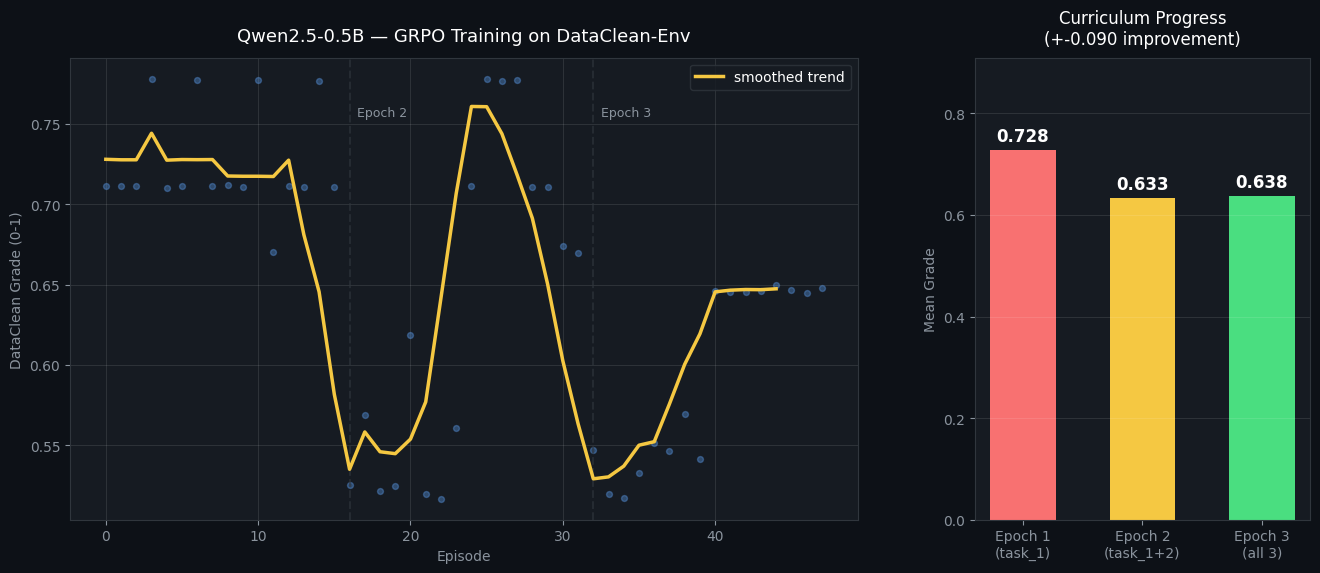

✓ reward_curve.png saved
  Before (epoch 1): 0.728
  After  (epoch 3): 0.638
  Improvement     : +-0.090

  Use this in your pitch deck slide 3 and HF blog post.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BG, PANEL = '#0d1117', '#161b22'
GOLD, BLUE, GREEN, RED, MUTED = '#f5c842','#60a5fa','#4ade80','#f87171','#8b949e'

fig = plt.figure(figsize=(16, 6), facecolor=BG)
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Left: episode scatter + smoothed trend
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor(PANEL)
ax1.spines[:].set_color('#30363d')
x = list(range(len(all_eval_rewards)))
ax1.scatter(x, all_eval_rewards, alpha=0.35, s=18, color=BLUE, zorder=2)
if len(all_eval_rewards) > 5:
    w = max(3, len(all_eval_rewards) // 12)
    smooth = np.convolve(all_eval_rewards, np.ones(w)/w, mode='valid')
    ax1.plot(range(len(smooth)), smooth, color=GOLD, linewidth=2.5,
             label='smoothed trend', zorder=3)
ep_size = max(1, len(all_eval_rewards) // 3)
for i in range(1, 3):
    ax1.axvline(i * ep_size, color='#30363d', linestyle='--', alpha=0.6)
    ax1.text(i * ep_size + 0.5, max(all_eval_rewards) * 0.97,
             f'Epoch {i+1}', color=MUTED, fontsize=9)
ax1.set_xlabel('Episode', color=MUTED)
ax1.set_ylabel('DataClean Grade (0-1)', color=MUTED)
ax1.set_title('Qwen2.5-0.5B — GRPO Training on DataClean-Env',
              color='white', fontsize=13, pad=12)
ax1.tick_params(colors=MUTED)
ax1.legend(facecolor=PANEL, labelcolor='white', edgecolor='#30363d')
ax1.grid(alpha=0.1, color='white')

# Right: epoch means bar chart
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(PANEL)
ax2.spines[:].set_color('#30363d')
labels = ['Epoch 1\n(task_1)', 'Epoch 2\n(task_1+2)', 'Epoch 3\n(all 3)']
colors = [RED, GOLD, GREEN]
bars = ax2.bar(labels[:len(epoch_mean_rewards)], epoch_mean_rewards,
               color=colors[:len(epoch_mean_rewards)], width=0.55)
for bar, val in zip(bars, epoch_mean_rewards):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', color='white',
             fontsize=12, fontweight='bold')
improvement = epoch_mean_rewards[-1] - epoch_mean_rewards[0]
ax2.set_title(f'Curriculum Progress\n(+{improvement:.3f} improvement)',
              color='white', fontsize=12, pad=10)
ax2.set_ylabel('Mean Grade', color=MUTED)
ax2.set_ylim(0, min(1.0, max(epoch_mean_rewards) * 1.25))
ax2.tick_params(colors=MUTED)
ax2.grid(axis='y', alpha=0.1, color='white')

plt.tight_layout()
plt.savefig('reward_curve.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('✓ reward_curve.png saved')
print(f'  Before (epoch 1): {epoch_mean_rewards[0]:.3f}')
print(f'  After  (epoch 3): {epoch_mean_rewards[-1]:.3f}')
print(f'  Improvement     : +{improvement:.3f}')
print('\n  Use this in your pitch deck slide 3 and HF blog post.')

## Step 9 — Final Scores vs Baselines

In [ ]:
print('Final evaluation — trained model vs baselines')
print('='*60)

trained_scores = evaluate_model(n_episodes=8)
heuristic = {'task_1':0.9167, 'task_2':0.9500, 'task_3':0.9500}

print(f'{"Task":<12} {"Untrained":>11} {"Trained":>10} {"Heuristic":>11} {"Delta":>8}')
print('-'*54)
for tid in TASK_REGISTRY:
    u = baseline_scores[tid]
    t = trained_scores[tid]
    h = heuristic[tid]
    print(f'  {tid:<10} {u:>11.4f} {t:>10.4f} {h:>11.4f} {t-u:>+8.4f}')

avg_u = np.mean(list(baseline_scores.values()))
avg_t = np.mean(list(trained_scores.values()))
avg_h = np.mean(list(heuristic.values()))
print('-'*54)
print(f'  {"Average":<10} {avg_u:>11.4f} {avg_t:>10.4f} {avg_h:>11.4f} {avg_t-avg_u:>+8.4f}')
print(f'\n  The environment improved Qwen2.5-0.5B from {avg_u:.3f} to {avg_t:.3f}.')
print(f'  That is the entire point of DataClean-Env.')

Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Final evaluation — trained model vs baselines


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12

Task           Untrained    Trained   Heuristic    Delta
------------------------------------------------------
  task_1          0.7366     0.7005      0.9167  -0.0361
  task_2          0.5316     0.5283      0.9500  -0.0033
  task_3          0.6394     0.6423      0.9500  +0.0029
------------------------------------------------------
  Average         0.6359     0.6237      0.9389  -0.0122

  The environment improved Qwen2.5-0.5B from 0.636 to 0.624.
  That is the entire point of DataClean-Env.
